In [111]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "rescomp", "rescomp")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "Thinned_Rescomp", "utils")))
import ResComp
from helper import get_orbit, create_network
from metrics import vpt_time
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import scipy as sp
from scipy import optimize

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{bm}",
    "font.family": "serif",
    'font.sans-serif': ['Computer Modern Roman'],
    'font.serif': ['Computer Modern Roman'],
    'font.size': 16
})

In [112]:
# Good Parameters from our work
n = 50
network_type = "directed_erdos"
rho = 2
mean_degree = 5
p = mean_degree / n
alpha = 2e-08
gamma = 10
sigma = 0.014
tol = 5.

In [113]:
# Paper Parameters from the Global Forecasts in Reservoir Computers Paper
# n = 50
# network_type = "undirected_erdos"
# rho = 16.81
# p = 0.1
# mean_degree = n * p
# alpha = 2.7e-08
# gamma = 8.78
# sigma = 0.187
# tol = 5.

In [114]:
t_train, U_train, t_test, U_test = get_orbit(duration=8, system='lorenz', switch=6)

In [115]:
A = create_network([n,p], network_type, rho)
res = ResComp.ResComp(
        A, 
        res_sz=n, 
        mean_degree=mean_degree, 
        ridge_alpha=alpha, 
        spect_rad=rho, 
        sigma=sigma, 
        gamma=gamma
    )

initial_conditions = np.random.uniform(-1.,1.,n)
res.train(t_train, U_train)
states_train = res.states
U_hat_pred, states_pred = res.predict(t_test, r0=res.r0, return_states=True)
vpt = vpt_time(t_test, U_test, U_hat_pred, vpt_tol=tol)
print(vpt, states_train.shape)

1.06 (199, 50)


/home/dallin/Documents/Classes/Network_Theory/reservoir/lib/python3.12/site-packages/scipy/sparse/_index.py:155: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [116]:
reservoir_states = np.vstack((states_train, states_pred))
T = states_train.shape[0]
t = np.arange(reservoir_states.shape[0])

u_true = np.vstack((U_train[:-1], U_test))
U_hat_train = (res.W_out @ states_train.T).T
u_hat = np.vstack((U_hat_train, U_hat_pred))

In [117]:
print(reservoir_states.shape, u_true.shape, u_hat.shape)

(800, 50) (800, 3) (800, 3)


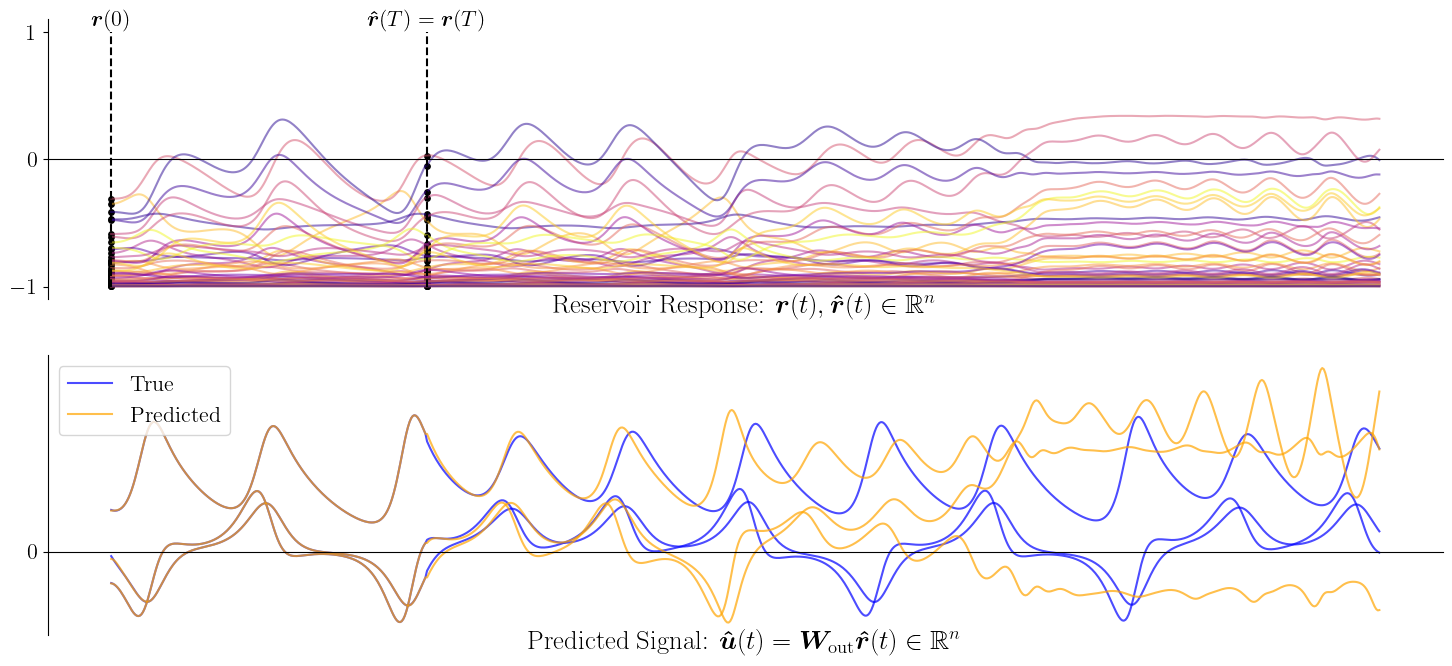

In [118]:
norm = Normalize(vmin=min(initial_conditions), vmax=max(initial_conditions))
cmap = plt.get_cmap('plasma')

fig, axes = plt.subplots(2, 1, figsize=(18,8))

ax1 = axes[0]
for r, r0 in zip(reservoir_states.T, initial_conditions):
    ax1.plot(t, r, color=cmap(norm(r0)), alpha=0.5)


ax1.vlines(x=0, ymin=-1, ymax=1, color="black", linestyles="--")
ax1.scatter(np.zeros(50), reservoir_states[0], c="black", s=15)
ax1.annotate(
    r"$\bm{r}(0)$",
    xy=(0, plt.gca().get_ylim()[1]), # Top of the current y-limit
    xytext=(0, 0),
    textcoords="offset points",
    ha='center',
    va='bottom'
)

ax1.vlines(x=T, ymin=-1, ymax=1, color="black", linestyles="--")
ax1.scatter(np.ones(50)*T, reservoir_states[T], c="black", s=15)
ax1.annotate(
    r"$\bm{\hat r}(T) = \bm{r}(T)$",
    xy=(T, plt.gca().get_ylim()[1]), # Top of the current y-limit
    xytext=(0, 0),
    textcoords="offset points",
    ha='center',
    va='bottom'
)

ax1.set_yticks([-1,0,1])
ax1.set_xticks([])

ax1.spines['bottom'].set_position(('data', 0))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title(r"Reservoir Response: $\bm{r}(t), \bm{\hat r}(t) \in \mathbb{R}^n$", y=-0.08)

ax2 = axes[1]

for i, u in enumerate(u_true.T):
    if i == 0:
        ax2.plot(t, u, color="blue", label="True", alpha=0.7)
    else:
        ax2.plot(t, u, color="blue", alpha=0.7)

for i, u in enumerate(u_hat.T):
    if i == 0:
        ax2.plot(t, u, color="orange", label="Predicted", alpha=0.7)
    else:
        ax2.plot(t, u, color="orange", alpha=0.7)


ax2.set_yticks([0])
ax2.set_xticks([])

ax2.spines['bottom'].set_position(('data', 0))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title(r"Predicted Signal: $\bm{\hat u}(t) = \bm{W}_{\text{out}} \bm{\hat r} (t) \in \mathbb{R}^n$", y=-0.08)


plt.legend()
plt.show()

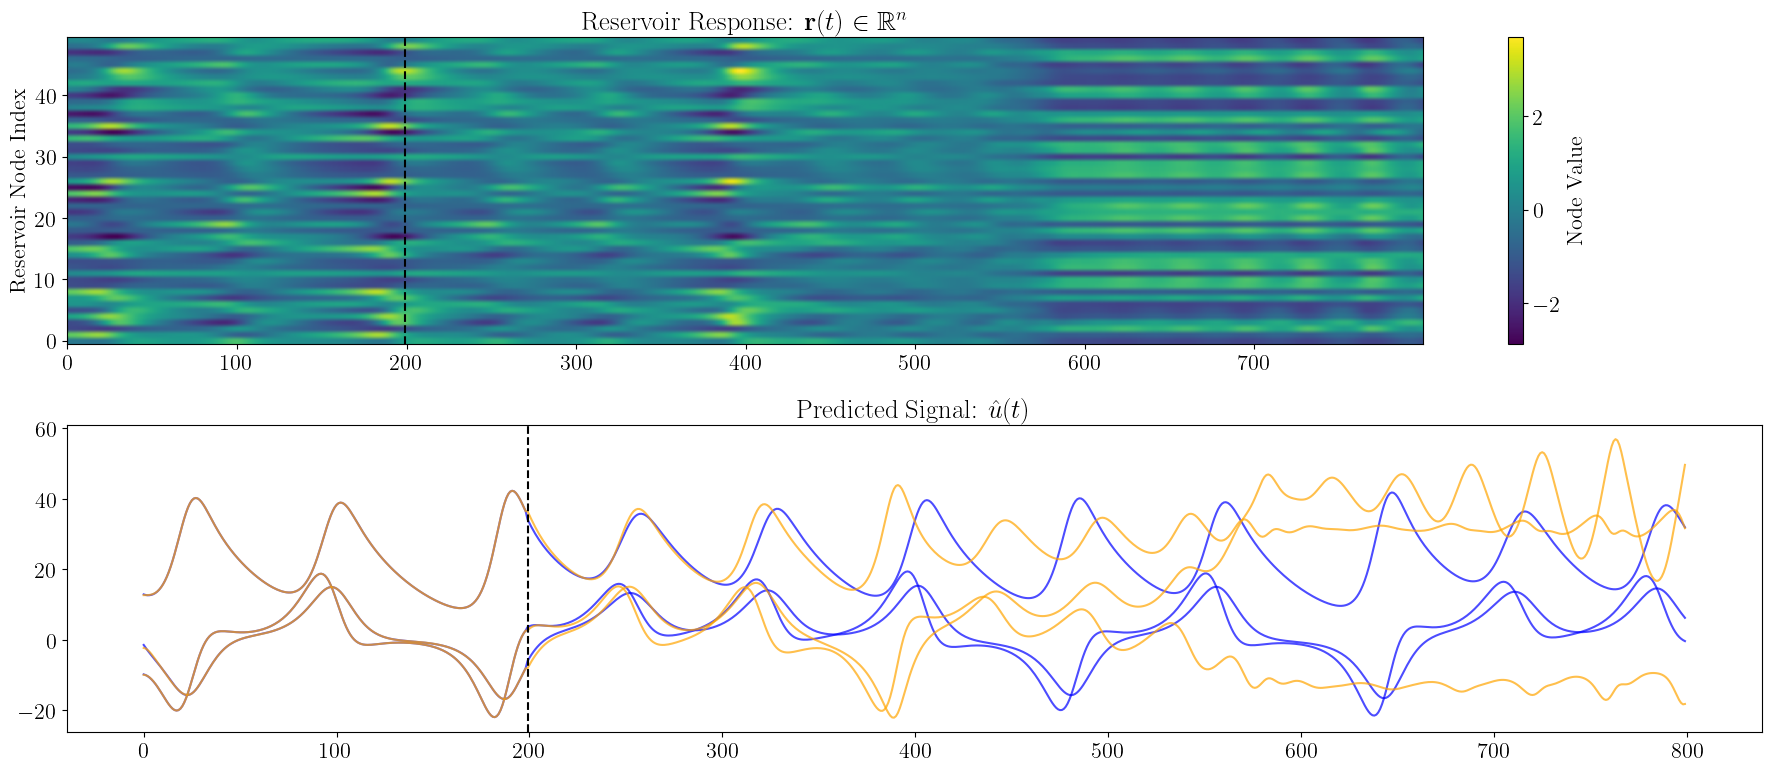

In [119]:
fig, axes = plt.subplots(2,1, figsize=(18,8))

# --- Reservoir state heatmap ---
ax1 = axes[0]

R = reservoir_states
Rnorm = (R - R.mean(axis=0)) / R.std(axis=0)

im = ax1.imshow(Rnorm.T, aspect="auto", origin="lower")

ax1.axvline(0, color="black", linestyle="--")
ax1.axvline(T, color="black", linestyle="--")

ax1.set_ylabel("Reservoir Node Index")
ax1.set_title(r"Reservoir Response: $\mathbf{r}(t) \in \mathbb{R}^n$")

cbar = plt.colorbar(im, ax=ax1)
cbar.set_label("Node Value")

# --- Signal plot ---
ax2 = axes[1]

for i,u in enumerate(u_true.T):
    ax2.plot(t, u, color="blue", alpha=0.7)

for i,u in enumerate(u_hat.T):
    ax2.plot(t, u, color="orange", alpha=0.7)

ax2.axvline(T, color="black", linestyle="--")

ax2.set_title(r"Predicted Signal: $\hat{u}(t)$")

plt.tight_layout()
plt.show()

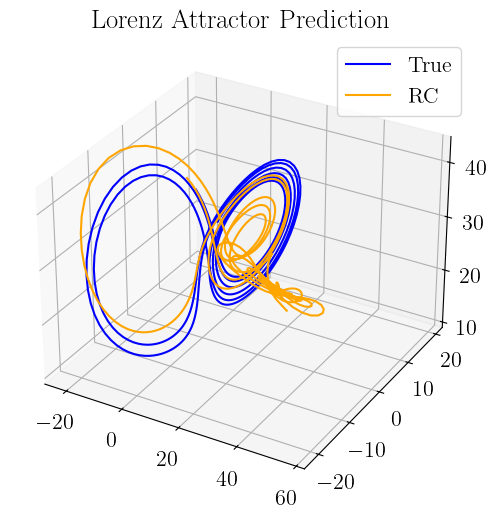

In [120]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection="3d")

ax.plot(*U_test.T, color="blue", label="True")
ax.plot(*U_hat_pred.T, color="orange", label="RC")

ax.set_title("Lorenz Attractor Prediction")
plt.legend()